
# O **pacto federativo**, em dinheiro → a 3‑layer gradient‑Sankey reel
### A hands‑on project with **gradient‑sankey** — built *com todo cuidado e carinho* 💙

Welcome! 👋 Most tutorials in this repo draw a **two‑column** Sankey. This one is different: we build a
real **three‑layer** flow that tells the story of Brazil's **federative pact** as *money* — how much
**federal tax each state pays to the Union**, and how much comes **back** as **constitutional transfers**.

> The punchline is built into the picture: most federal tax **does not** return to the state as a
> constitutional transfer. The rest funds **national‑level spending** (INSS, SUS, public debt, federal
> payroll). We make that honest by adding a **balance node**, `Gasto da União`, so the Union hub
> **conserves** (everything in = everything out).

---

### What we'll build

A **stacked ranking race** with **three columns**, animated **2016 → 2021**:

```
   Layer 1  the states        Layer 2          Layer 3  the states again
   (sized by TAX PAID)    →    "União"     →    (sized by TRANSFERS BACK)
                                                 + "Gasto da União"  (the balance)
```

- **Left** — each state, ribbon width = **federal tax collected** (`paga`, R$ bi).
- **Middle** — a single hub, **União**, where every state's tax pools.
- **Right** — the **same states**, ribbon width = **constitutional transfers received** (`recebe`),
  **plus** a dark **`Gasto da União`** node = *(total paga − total recebe)*: the ~90% that stays
  federal. So the hub balances.

To keep it readable we show the **top‑12 states by tax paid** individually and fold the other 15 into a
**`Demais estados`** bucket on **both** sides.

### Learning outcomes

1. Combine **two free, no‑auth public sources** into one tidy table: **Receita Federal** federal‑tax
   arrecadação (monthly `.ODS` files) + **Tesouro Transparente CKAN** constitutional transfers.
2. Parse a real **`.ODS` spreadsheet** with `pandas` + `odfpy`, and handle a real CKAN quirk
   (the 2016 split file + a pre‑2016 consolidated resource).
3. Build a **three‑layer** flow table by emitting **two link hops per year** into one tidy frame.
4. Add a **balance node** so a hub **conserves** (in == out) — an honest, reusable accounting trick.
5. Apply **top‑N + "Demais"** aggregation to tame a 27‑state table, and read the pact in the picture.

> **This notebook is fully self‑contained.** It clones‑and‑runs from the gradient‑sankey repo: it
> imports only `gradient_sankey` (the committed module at the repo root), the Python standard library,
> and the pip packages `pandas`, `requests` and `odfpy` (for the `.ODS` reading). Every data fetcher and
> every helper is **inlined below as a teaching step**, so you can read the whole ETL pipeline end to
> end. 💙



## 1 · Setup & install

The library lives in this repo as a single module, `gradient_sankey.py`, at the **repo root**. We add the
repo root to `sys.path` so we always get the **local** copy with the newest features:

```bash
pip install gradient-sankey pandas requests odfpy   # the public packages
# odfpy lets pandas read the Receita Federal .ODS spreadsheets
# this notebook uses the LOCAL repo copy of gradient_sankey via sys.path (see below)
```

> ⚠️ **Heads‑up — newest features.** This reel leans on capabilities in `gradient_sankey.py` that may be
> newer than the pinned PyPI release:
> - the **layer‑total value axis** (`yaxis_node`) with **`value_prefix="R$"`** and
>   **`yaxis_suffix=" bi"`** — a **reais** axis,
> - **`yaxis_gap`** and **`layer0_label_side`** to place the axis and the node labels,
> - the **`overlay_band`** control (push the footer line chart lower, clear of the Sankey),
> - the overlay styling kwargs (`overlay_value_suffix`, `overlay_badge`, `overlay_x_labels`),
> - **multi‑layer** parallel rendering (`SankeyRaceMultiLayerParallel` with **3** layers).
>
> Importing the local module via `sys.path` (below) makes all of these work today. 🎁

Rendering an **MP4** needs **FFmpeg** on your PATH — but the still frames (`save_frame`) need nothing
extra, so the notebook stays runnable even without FFmpeg.


In [1]:
import os, sys, io, re, json, pathlib

# --- import the LOCAL gradient_sankey from the repo root (committed module) ---
# This notebook lives in notebooks/, so the repo root is one level up.
REPO_ROOT = os.path.abspath("..")                      # notebooks/  ->  repo root
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import pandas as pd
import requests
from IPython.display import Image, display

import gradient_sankey as gs
from gradient_sankey import SankeyRaceMultiLayerParallel as Sankey

# where we'll drop the rendered stills / sample clip (kept out of the repo root)
ASSETS = os.path.abspath("gallery_assets"); os.makedirs(ASSETS, exist_ok=True)

# a LOCAL, gitignored cache for the source downloads, so a re-run is instant.
# Re-fetching from Receita/Tesouro on a clean run is fine (just slower).
CACHE = pathlib.Path(os.path.abspath(".nbcache")); CACHE.mkdir(parents=True, exist_ok=True)

def show(path, w=900):
    return Image(filename=path, width=w)

print("gradient-sankey version:", gs.__version__)
print("pandas:", pd.__version__)
print("cache ->", CACHE)


gradient-sankey version: 1.2.2
pandas: 3.0.1
cache -> C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\.nbcache



## 2 · The vocabulary — states, regions, and the two no‑auth sources

Before any data, let's name the **27 states** (UFs), map each to one of Brazil's **five regions**
(N / NE / CO / SE / S — we'll colour the diagram by region so it reads as a geography), and pin the two
**public, no‑auth** endpoints we'll fetch from.


In [2]:
UFS = ["AC", "AL", "AM", "AP", "BA", "CE", "DF", "ES", "GO", "MA", "MG", "MS", "MT",
       "PA", "PB", "PE", "PI", "PR", "RJ", "RN", "RO", "RR", "RS", "SC", "SE", "SP", "TO"]
UF_NAME = {"AC": "Acre", "AL": "Alagoas", "AM": "Amazonas", "AP": "Amapá", "BA": "Bahia",
           "CE": "Ceará", "DF": "Distrito Federal", "ES": "Espírito Santo", "GO": "Goiás",
           "MA": "Maranhão", "MG": "Minas Gerais", "MS": "Mato Grosso do Sul",
           "MT": "Mato Grosso", "PA": "Pará", "PB": "Paraíba", "PE": "Pernambuco",
           "PI": "Piauí", "PR": "Paraná", "RJ": "Rio de Janeiro", "RN": "Rio G. do Norte",
           "RO": "Rondônia", "RR": "Roraima", "RS": "Rio G. do Sul", "SC": "Santa Catarina",
           "SE": "Sergipe", "SP": "São Paulo", "TO": "Tocantins"}
# UF -> macro-region (used for the diagram colours: warm in the N/NE, cool in the S/SE)
REGIAO = {"AC": "N", "AM": "N", "AP": "N", "PA": "N", "RO": "N", "RR": "N", "TO": "N",
          "AL": "NE", "BA": "NE", "CE": "NE", "MA": "NE", "PB": "NE", "PE": "NE",
          "PI": "NE", "RN": "NE", "SE": "NE", "DF": "CO", "GO": "CO", "MS": "CO",
          "MT": "CO", "ES": "SE", "MG": "SE", "RJ": "SE", "SP": "SE",
          "PR": "S", "RS": "S", "SC": "S"}

# --- the two NO-AUTH public endpoints -------------------------------------------
# (1) Receita Federal: a year page that links the 12 monthly .ODS arrecadacao files.
RF_YEAR = ("https://www.gov.br/receitafederal/pt-br/acesso-a-informacao/dados-abertos/"
           "receitadata/arrecadacao/arrecadacao-por-estado/arrecadacao-uf-{year}")
# (2) Tesouro Transparente CKAN package listing every transfers resource.
TESOURO_PKG = ("https://www.tesourotransparente.gov.br/ckan/api/3/action/"
               "package_show?id=transferencias-constitucionais-para-estados")

# a polite User-Agent + a tiny GET helper used by every fetch below
UA = {"User-Agent": "gradient-sankey-tutorial/1.0 (+github.com/FG-SC/gradient-sankey)"}
def _get(url):
    r = requests.get(url, headers=UA, timeout=120)
    r.raise_for_status()
    return r

print(f"{len(UFS)} states; regions:", sorted(set(REGIAO.values())))
print("paga  <- Receita Federal .ODS (no auth, reliable 2016-2021)")
print("recebe <- Tesouro Transparente CKAN (no auth)")


27 states; regions: ['CO', 'N', 'NE', 'S', 'SE']
paga  <- Receita Federal .ODS (no auth, reliable 2016-2021)
recebe <- Tesouro Transparente CKAN (no auth)



## 3 · EXTRACT

### 3a · `paga` — federal tax per state, from the Receita Federal **`.ODS`** files 📑

The first side of the pact is the **federal tax a state collects** (`paga`). Receita Federal publishes it
as **monthly `.ODS` spreadsheets**, one page per year:

```
https://www.gov.br/receitafederal/.../arrecadacao-por-estado/arrecadacao-uf-{year}
```

Our fetcher (a) scrapes the year page for the **`.ods` links**, (b) reads each monthly file with
`pandas.read_excel(..., engine="odf")` (that's what **`odfpy`** is for), (c) finds the header row carrying
the UF codes and the **`TOTAL GERAL`** row, and (d) sums that row per state across all 12 months. The whole
yearly total is **disk‑cached** to our local `.nbcache/` so a re‑run is instant.

> ### 💡 Why `.ODS`, and not BigQuery?
> The production reel can also pull recent arrecadação (to 2024) from **Base dos Dados on BigQuery**
> (`basedosdados.br_rf_arrecadacao.uf`) — but that **bills queries to a Google Cloud project** and needs
> ADC credentials a cloner won't have. So **this self‑contained notebook uses only the no‑auth `.ODS`
> source**, which is reliable for **2016–2021**. *(If you do have GCP set up, the BigQuery path extends
> the same series to 2024 with the right credentials. We don't call it here.)*

> ### 🪤 The parsing trap
> The `.ODS` files aren't a clean table — the UF codes sit on some header row partway down, and the
> per‑state total is a `TOTAL GERAL` row. We locate both **by content** (find the row that contains both
> `SP` and `RJ`; find the row whose first cell starts with `TOTAL GERAL`) rather than by fixed indices, so
> small layout drifts between months don't break us.


In [3]:
def arrecadacao_uf(year, cache=CACHE):
    """Total federal tax collected per UF in `year` (R$), from Receita's monthly .ODS.
    No auth; reliable 2016-2021. Result is disk-cached as one small JSON per year."""
    cf = cache / f"rf_arrecadacao_{year}.json"
    if cf.exists():
        return json.loads(cf.read_text(encoding="utf-8"))

    # (a) scrape the year page for the monthly .ods hrefs (strip a trailing /view; de-dup)
    html = _get(RF_YEAR.format(year=year)).text
    ods = []
    for h in re.findall(r'href="([^"]+?\.ods)(?:/view)?"', html):
        u = h if h.startswith("http") else "https://www.gov.br" + h
        if u not in ods:
            ods.append(u)

    totals = {uf: 0.0 for uf in UFS}
    for u in ods:
        # (b) read the .ODS with the odfpy engine; header=None -> we locate rows by content
        df = pd.read_excel(io.BytesIO(_get(u).content), engine="odf", header=None)
        # (c) header row carries the UF codes; the per-UF total is the "TOTAL GERAL" row
        hdr = next(i for i in range(len(df))
                   if {"SP", "RJ"} <= {str(x).strip() for x in df.iloc[i].tolist()})
        col_uf = {j: str(v).strip() for j, v in enumerate(df.iloc[hdr]) if str(v).strip() in UFS}
        trow = next(i for i in range(hdr, len(df))
                    if str(df.iloc[i, 0]).strip().upper().startswith("TOTAL GERAL"))
        # (d) sum the TOTAL GERAL row per state across all 12 monthly files
        for j, uf in col_uf.items():
            try:
                totals[uf] += float(df.iloc[trow, j])
            except (ValueError, TypeError):
                pass
    cf.write_text(json.dumps(totals), encoding="utf-8")
    return totals

# smoke-test one year so the parse is visible (downloads ~12 .ODS the first time)
_probe_year = 2021
_paga = arrecadacao_uf(_probe_year)
print(f"federal tax collected per state, R$ bi — {_probe_year} (top 6):")
for uf in sorted(_paga, key=_paga.get, reverse=True)[:6]:
    print(f"  {uf} {UF_NAME[uf]:<16} R${_paga[uf]/1e9:8,.1f} bi")
print(f"  ... TOTAL R${sum(_paga.values())/1e9:,.0f} bi across {len(UFS)} states")


federal tax collected per state, R$ bi — 2021 (top 6):
  SP São Paulo        R$   715.7 bi
  RJ Rio de Janeiro   R$   329.3 bi
  DF Distrito Federal R$   137.5 bi
  MG Minas Gerais     R$   125.8 bi
  SC Santa Catarina   R$    97.2 bi
  PR Paraná           R$    91.9 bi
  ... TOTAL R$1,879 bi across 27 states



### 3b · `recebe` — constitutional transfers, from **Tesouro Transparente** (CKAN) 🤝

The other side is the **constitutional transfers** a state gets back (`recebe`): **FPE + FPEX + Fundeb +
ITR**, the redistribution mechanism of the pact. Tesouro Transparente exposes them through a **CKAN** API:
one `package_show` call lists every resource (a CSV per month/period), and we sum the **three "decêndios"**
(10‑day slices) per state. **No auth, ever.**

> ### 🧩 Two real‑world CKAN quirks (the reason this isn't one clean loop)
> 1. **The 2016 split.** 2016 is split across files: **Jan–Jul** lives in a one‑off
>    `Transferencia_Estados_2016-jan-jul.csv`, while **Aug–Dec** are in the normal monthly
>    `Transferencia_Mensal_Estados_2016MM.csv` files. We handle both.
> 2. **The pre‑2016 consolidated file.** Years **≤ 2015** aren't monthly at all — they're inside one
>    big **1997–2015 consolidated CSV**. The CKAN dataset has several *similarly named* resources whose
>    URLs don't match, so we hard‑code the **exact verified resource id** for the real consolidated file
>    and filter it by `ANO`. *(Our 2016–2021 window only needs the 2016 split quirk, but we keep the
>    pre‑2016 path so you can widen the window backwards.)*

The CSVs are `;`‑separated, **latin‑1** encoded, and use a comma decimal — all handled below.


In [4]:
# exact verified CKAN resource for the consolidated 1997-2015 transfers file (years <= 2015)
_CONSOLIDATED_1997_2015 = (
    "https://www.tesourotransparente.gov.br/ckan/dataset/"
    "8add38c3-cf27-4428-940e-806548cac95c/resource/"
    "1bb3522d-28ef-4665-88b1-8bcc9d0904d4/download/transferenciaestados1997-2015.csv.csv")

def _accumulate_transf(df, totals):
    """Sum the three 'decêndio' columns per UF onto `totals` (decêndio = a 10-day slice)."""
    df.columns = [c.strip() for c in df.columns]
    uf_col = next(c for c in df.columns if c.upper() == "UF")
    dec = [c for c in df.columns if "Dec" in c or "dec" in c]   # "1º Decêndio" etc. (mojibake-safe)
    for _, row in df.iterrows():
        uf = str(row[uf_col]).strip()
        if uf in totals:
            for c in dec:
                try:
                    totals[uf] += float(str(row[c]).replace(",", "."))   # comma decimal -> float
                except (ValueError, TypeError):
                    pass

def transferencias_uf(year, cache=CACHE):
    """Total constitutional transfers per UF in `year` (R$), from Tesouro CKAN.
    2016+ = monthly CSVs (2016 is split jan-jul + aug-dec); <=2015 = the consolidated
    1997-2015 file, filtered by year. Disk-cached as one small JSON per year."""
    cf = cache / f"tesouro_transf_{year}.json"
    if cf.exists():
        return json.loads(cf.read_text(encoding="utf-8"))

    res = _get(TESOURO_PKG).json()["result"]["resources"]
    by_name = {x.get("name", ""): x.get("url") for x in res}
    totals = {uf: 0.0 for uf in UFS}

    if year <= 2015:
        rawf = cache / "tesouro_transf_1997-2015.csv"          # cache the ~3.8 MB file once
        if not rawf.exists():
            rawf.write_bytes(_get(_CONSOLIDATED_1997_2015).content)
        df = pd.read_csv(rawf, sep=";", encoding="latin-1")
        df.columns = [c.strip() for c in df.columns]
        ano_col = next(c for c in df.columns if c.upper() == "ANO")
        _accumulate_transf(df[df[ano_col].astype(str).str.strip() == str(year)], totals)
    else:
        if year == 2016:
            # 2016 is split: Jan-Jul in a one-off file, Aug-Dec in the monthly files.
            jj = by_name.get("Transferencia_Estados_2016-jan-jul.csv")
            if jj:
                _accumulate_transf(pd.read_csv(io.BytesIO(_get(jj).content),
                                               sep=";", encoding="latin-1"), totals)
            months = range(8, 13)
        else:
            months = range(1, 13)
        for m in months:
            url = by_name.get(f"Transferencia_Mensal_Estados_{year}{m:02d}.csv")
            if url:
                _accumulate_transf(pd.read_csv(io.BytesIO(_get(url).content),
                                               sep=";", encoding="latin-1"), totals)

    cf.write_text(json.dumps(totals), encoding="utf-8")
    return totals

# smoke-test the SAME year so both sides are visible
_recebe = transferencias_uf(_probe_year)
print(f"constitutional transfers received per state, R$ bi — {_probe_year} (top 6):")
for uf in sorted(_recebe, key=_recebe.get, reverse=True)[:6]:
    print(f"  {uf} {UF_NAME[uf]:<16} R${_recebe[uf]/1e9:7,.1f} bi")
print(f"  ... TOTAL transfers R${sum(_recebe.values())/1e9:,.0f} bi"
      f"  ({100*sum(_recebe.values())/sum(_paga.values()):.1f}% of federal tax)")


constitutional transfers received per state, R$ bi — 2021 (top 6):
  SP São Paulo        R$   23.6 bi
  RJ Rio de Janeiro   R$   21.7 bi
  MG Minas Gerais     R$   16.0 bi
  BA Bahia            R$   13.2 bi
  PA Pará             R$    9.9 bi
  PE Pernambuco       R$    9.0 bi
  ... TOTAL transfers R$204 bi  (10.9% of federal tax)



### 3c · The IPCA deflator — an optional **real‑R\$** view 💵

Our `paga`/`recebe` are **nominal** reais, so part of any 2016→2021 growth is just **inflation**, not a
bigger pact. To optionally strip that out, we pull the **IPCA** (Brazil's official CPI) from the Banco
Central's **SGS series 433** — a free, no‑auth JSON API — build a cumulative price index, take each year's
**average price level**, and form a deflator `{year → factor}` that converts nominal R\$ of `year` into
**constant R\$ of a base year**. We keep this **off by default** (`REAL = False`) so the headline figures
stay nominal; flip it on to see the inflation‑adjusted series.


In [5]:
def ipca_deflator(base_year=2021, cache=CACHE):
    """{year: factor} converting NOMINAL R$ of `year` into REAL R$ of `base_year`,
    using the IPCA (BCB SGS series 433, monthly %), year-average price level. No auth."""
    cf = cache / f"ipca_deflator_{base_year}.json"
    if cf.exists():
        return {int(k): v for k, v in json.loads(cf.read_text(encoding="utf-8")).items()}
    u = ("https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados?formato=json"
         "&dataInicial=01/01/1999&dataFinal=31/12/2024")
    d = pd.DataFrame(_get(u).json())
    d["data"] = pd.to_datetime(d["data"], format="%d/%m/%Y")
    d["idx"] = (1 + d["valor"].astype(float) / 100).cumprod()      # cumulative price index
    lvl = d.groupby(d["data"].dt.year)["idx"].mean()               # year-average price level
    defl = {int(y): float(lvl[base_year] / lvl[y]) for y in lvl.index}
    cf.write_text(json.dumps(defl), encoding="utf-8")
    return defl

REAL = False          # set True to deflate everything to constant R$ of the base year below
BASE_YEAR = 2021
_defl = ipca_deflator(BASE_YEAR)
print(f"IPCA deflator -> constant R$ of {BASE_YEAR} (a factor per year):")
for y in range(2016, 2022):
    print(f"  {y}: x{_defl.get(y, 1.0):.4f}")
print(f"\nREAL = {REAL}  (nominal R$ unless you flip this to True)")


IPCA deflator -> constant R$ of 2021 (a factor per year):
  2016: x1.2434
  2017: x1.2020
  2018: x1.1595
  2019: x1.1178
  2020: x1.0830
  2021: x1.0000

REAL = False  (nominal R$ unless you flip this to True)



## 4 · TRANSFORM — one tidy balance per state

Now we wrap the two sources into a single per‑state **balance**: one row per UF with `paga` (federal tax)
and `recebe` (constitutional transfers), both in **R\$ billions**, plus `net = paga − recebe`. If
`REAL=True`, both columns are multiplied by the IPCA factor for that year. This is the `fiscal_balance`
helper — the one function the whole reel rests on.


In [6]:
def fiscal_balance(year, real=REAL, base_year=BASE_YEAR):
    """One row per UF: paga (federal tax) and recebe (constitutional transfers), R$ bi.
    No-auth sources only: arrecadacao_uf (.ODS) + transferencias_uf (CKAN).
    real=True deflates both to constant R$ of base_year via the IPCA."""
    pay = arrecadacao_uf(year)
    rec = transferencias_uf(year)
    rows = [{"uf": uf, "estado": UF_NAME[uf], "regiao": REGIAO[uf],
             "paga": pay.get(uf, 0) / 1e9, "recebe": rec.get(uf, 0) / 1e9} for uf in UFS]
    df = pd.DataFrame(rows)
    if real:
        f = ipca_deflator(base_year).get(year, 1.0)
        df["paga"] *= f
        df["recebe"] *= f
    df["net"] = df["paga"] - df["recebe"]
    return df.sort_values("paga", ascending=False).reset_index(drop=True)

# our no-auth window
Y0, Y1 = 2016, 2021

latest = fiscal_balance(Y1)
print(f"federal tax PAID vs constitutional transfers RECEIVED, R$ bi — {Y1}\n")
print(latest.head(12).to_string(index=False, float_format=lambda v: f"{v:,.1f}"))

tot_p, tot_r = latest.paga.sum(), latest.recebe.sum()
print(f"\nTOTAL paga {tot_p:,.0f} bi  |  recebe {tot_r:,.0f} bi"
      f"  ->  transfers are only {100*tot_r/tot_p:.1f}% of federal tax")


federal tax PAID vs constitutional transfers RECEIVED, R$ bi — 2021

uf           estado regiao  paga  recebe   net
SP        São Paulo     SE 715.7    23.6 692.1
RJ   Rio de Janeiro     SE 329.3    21.7 307.6
DF Distrito Federal     CO 137.5     3.1 134.4
MG     Minas Gerais     SE 125.8    16.0 109.8
SC   Santa Catarina      S  97.2     4.5  92.7
PR           Paraná      S  91.9     8.8  83.1
RS    Rio G. do Sul      S  88.4     7.8  80.6
BA            Bahia     NE  40.7    13.2  27.5
PE       Pernambuco     NE  32.1     9.0  23.1
ES   Espírito Santo     SE  30.4     5.0  25.5
CE            Ceará     NE  30.1     8.8  21.3
GO            Goiás     CO  28.2     6.0  22.2

TOTAL paga 1,879 bi  |  recebe 204 bi  ->  transfers are only 10.9% of federal tax



There's the whole story in one table: **São Paulo** pays the most federal tax by far and gets a tiny
sliver back; the transfers total is **well under ~15%** of the tax total. Let's confirm the
**concentration** (how few states carry the tax base) and pull the **6‑year arc** — the numbers behind the
animation.


In [7]:
# how concentrated is the tax base? (top-12 share of total paga, latest year)
top12_share = 100 * latest.head(12).paga.sum() / latest.paga.sum()
print(f"top-12 states pay {top12_share:.1f}% of all federal tax ({Y1})")
print(f"SP alone pays {100*latest.iloc[0].paga/latest.paga.sum():.1f}%"
      f" and gets back {latest.iloc[0].recebe:.1f} bi on {latest.iloc[0].paga:.0f} bi paid\n")

# the 6-year arc: total tax, total transfers, and the 'stays federal' share
for y in range(Y0, Y1 + 1):
    d = fiscal_balance(y)
    p, r = d.paga.sum(), d.recebe.sum()
    print(f"  {y}: paga {p:7,.0f}  recebe {r:6,.0f} ({100*r/p:4.1f}%)"
          f"   stays federal {p-r:7,.0f} ({100*(p-r)/p:4.1f}%)")


top-12 states pay 93.0% of all federal tax (2021)
SP alone pays 38.1% and gets back 23.6 bi on 716 bi paid



  2016: paga   2,580  recebe    146 ( 5.7%)   stays federal   2,434 (94.3%)


  2017: paga   2,685  recebe    148 ( 5.5%)   stays federal   2,537 (94.5%)
  2018: paga   2,914  recebe    157 ( 5.4%)   stays federal   2,757 (94.6%)
  2019: paga   3,074  recebe    167 ( 5.4%)   stays federal   2,907 (94.6%)
  2020: paga   2,959  recebe    170 ( 5.7%)   stays federal   2,789 (94.3%)
  2021: paga   1,879  recebe    204 (10.9%)   stays federal   1,675 (89.1%)



## 5 · Build the three‑layer flows (the heart of this lesson) 🔑

A multi‑layer Sankey is fed the **same** tidy `[time, source, target, value]` frame as a 2‑layer one —
the trick is that **each year emits links at *both* hops**:

| hop | source → target | width |
|---|---|---|
| ① tax in | `state` → `União` | `paga` |
| ② transfer back | `União` → `state ` *(trailing space!)* | `recebe` |
| ③ the balance | `União` → `Gasto da União` | *(total paga − total recebe)* |

`from_dataframe` turns every `(source, target, value)` row into a ribbon, so mixing both hops in one
frame **is** how you build a 3‑layer Sankey.

> ### 🪪 Node‑name uniqueness — the trailing‑space trick
> The library requires **unique** node names **across all layers**. But our state appears **twice** —
> once paying (left) and once receiving (right). So the left node is the **bare code** (`"SP"`) and the
> right node is the **same code plus a trailing space** (`"SP "`). They **display identically** (the eye
> can't see a trailing space) yet are distinct keys. 🎩

> ### ⚖️ The balance node — why the hub conserves
> Into `União` flows **all** the tax (`Σ paga`). Out of it we send each state's **transfer** back —
> but those sum to only ~10–13% of what came in. To make the hub **balance** (in == out, as a Sankey
> physically must), we add one more out‑link to a node named **`Gasto da União`** carrying the
> remainder *(Σ paga − Σ recebe)*. That node **is** the honest message: the money that **stays federal**.
>
> 🛑 **Read this node honestly.** `Gasto da União` is **national spending**, and a large part of it
> **returns to the states** in other forms — **INSS** pensions paid to residents, **SUS** health funding,
> federal payroll in each state. So this picture is a **redistribution‑only view** — it shows the
> *constitutional transfer* mechanism, **not** a net "money lost to Brasília" claim. A naive
> `paga − recebe` reading **overstates** the imbalance, because `recebe` deliberately excludes those
> return flows. The point is the *shape* of the constitutional redistribution, not a per‑state P&L.

> ### 🧹 Top‑N + "Demais" — taming 27 states
> 27 states × 2 sides would be unreadable. We show the **top‑12 by all‑window `paga`** individually and
> fold the other 15 into **`Demais estados`** on each side. We pick the top‑12 **once, over the whole
> window**, so a state doesn't pop in and out of the named set year to year.


In [8]:
UNIAO = "Uniao"                       # ASCII node id for the hub
GASTO = "Gasto da Uniao"              # the balance node: paga - recebe (stays federal)
DEMAIS_PAGA = "Demais estados"        # paying-side aggregate (the other 15 states)
DEMAIS_RECEBE = "Demais estados "     # receiving-side aggregate (trailing space = unique)
TOP_N = 12

def fiscal_flows(y0, y1, top_n=TOP_N):
    """Build the 3-layer flow table. Returns (df, layer1, layer2, layer3, node_colors)."""
    years = list(range(y0, y1 + 1))
    balances = {y: fiscal_balance(y) for y in years}

    # decide the top-N ONCE, by all-window total `paga`, so node identity is stable
    allwin = pd.concat([balances[y][["uf", "paga"]] for y in years])
    top = (allwin.groupby("uf")["paga"].sum()
           .sort_values(ascending=False).head(top_n).index.tolist())
    top_set = set(top)

    rows = []
    for y in years:
        df = balances[y]
        tot_paga, tot_recebe = float(df.paga.sum()), float(df.recebe.sum())
        named = df[df.uf.isin(top_set)]
        rest = df[~df.uf.isin(top_set)]
        for r in named.itertuples():
            rows.append((y, r.uf, UNIAO, float(r.paga)))          # hop 1: state -> Uniao
            rows.append((y, UNIAO, f"{r.uf} ", float(r.recebe)))  # hop 2: Uniao -> state'
        rows.append((y, DEMAIS_PAGA, UNIAO, float(rest.paga.sum())))
        rows.append((y, UNIAO, DEMAIS_RECEBE, float(rest.recebe.sum())))
        rows.append((y, UNIAO, GASTO, tot_paga - tot_recebe))     # hop 3: the balance node

    flow = pd.DataFrame(rows, columns=["year", "source", "target", "value"])
    flow = flow[flow["value"] > 0].reset_index(drop=True)

    layer1 = top + [DEMAIS_PAGA]                                  # paying states
    layer2 = [UNIAO]                                              # the hub
    layer3 = [f"{u} " for u in top] + [DEMAIS_RECEBE, GASTO]      # receiving + balance

    # region -> colour (N/NE/CO/SE/S); Uniao neutral; Gasto dark gray; Demais slate
    REGION_COLORS = {"N": "#F4A261", "NE": "#E5484D", "CO": "#9B5DE5",
                     "SE": "#4EA8DE", "S": "#80ED99"}
    node_colors = {}
    for uf in top:
        c = REGION_COLORS.get(REGIAO[uf], "#888888")
        node_colors[uf] = c
        node_colors[f"{uf} "] = c
    node_colors[DEMAIS_PAGA] = node_colors[DEMAIS_RECEBE] = "#6B7280"
    node_colors[UNIAO] = "#9AA0A6"
    node_colors[GASTO] = "#3A3F44"
    return flow, layer1, layer2, layer3, node_colors

flow, layer1, layer2, layer3, node_colors = fiscal_flows(Y0, Y1)
print("layer1 (paga)  :", layer1)
print("layer2 (hub)   :", layer2)
print("layer3 (recebe):", [n.rstrip() + ("'" if n.endswith(" ") and n != "Demais estados " else "")
                            for n in layer3])  # show the trailing-space twins as code'
print(f"\n{len(flow)} link rows across {flow.year.nunique()} years")
flow.head(6)


layer1 (paga)  : ['SP', 'RJ', 'DF', 'MG', 'RS', 'PR', 'SC', 'BA', 'PE', 'CE', 'ES', 'GO', 'Demais estados']
layer2 (hub)   : ['Uniao']
layer3 (recebe): ["SP'", "RJ'", "DF'", "MG'", "RS'", "PR'", "SC'", "BA'", "PE'", "CE'", "ES'", "GO'", 'Demais estados', 'Gasto da Uniao']

162 link rows across 6 years


,year,source,target,value
0,2016,SP,Uniao,1037.595123
1,2016,Uniao,SP,18.284626
2,2016,RJ,Uniao,389.736956
3,2016,Uniao,RJ,8.110847
4,2016,DF,Uniao,322.870581
5,2016,Uniao,DF,2.430126



### Prove the hub conserves ⚖️

Before drawing anything, let's verify the accounting: for **every** year, the tax flowing **into**
`União` must equal the transfers + `Gasto da União` flowing **out**. If this holds, the Sankey is honest
and balanced.


In [9]:
for y in sorted(flow.year.unique()):
    f = flow[flow.year == y]
    into = f[f.target == UNIAO]["value"].sum()                       # all tax in
    out_all = f[f.source == UNIAO]["value"].sum()                    # transfers + Gasto out
    recebe = f[(f.source == UNIAO) & (f.target != GASTO)]["value"].sum()
    gasto = f[f.target == GASTO]["value"].sum()
    ok = "OK" if abs(into - out_all) < 1e-6 else "MISMATCH"
    print(f"  {y}: in {into:7,.0f}  ==  out {out_all:7,.0f}  [{ok}]"
          f"   | recebe {recebe:5,.0f} ({100*recebe/into:4.1f}%)"
          f"  Gasto {gasto:7,.0f} ({100*gasto/into:4.1f}%)")


  2016: in   2,580  ==  out   2,580  [OK]   | recebe   146 ( 5.7%)  Gasto   2,434 (94.3%)
  2017: in   2,685  ==  out   2,685  [OK]   | recebe   148 ( 5.5%)  Gasto   2,537 (94.5%)
  2018: in   2,914  ==  out   2,914  [OK]   | recebe   157 ( 5.4%)  Gasto   2,757 (94.6%)
  2019: in   3,074  ==  out   3,074  [OK]   | recebe   167 ( 5.4%)  Gasto   2,907 (94.6%)
  2020: in   2,959  ==  out   2,959  [OK]   | recebe   170 ( 5.7%)  Gasto   2,789 (94.3%)
  2021: in   1,879  ==  out   1,879  [OK]   | recebe   204 (10.9%)  Gasto   1,675 (89.1%)



## 6 · EXPLORE — sanity‑check the story before drawing it

Two quick views: **who pays vs who receives** in the latest year (the concentration), and the
**total‑tax arc** over the window (the *size of the pact* growing).


In [10]:
import matplotlib.pyplot as plt
plt.style.use("dark_background")

REGION_COLORS = {"N": "#F4A261", "NE": "#E5484D", "CO": "#9B5DE5", "SE": "#4EA8DE", "S": "#80ED99"}
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (1) top-12 states: tax paid vs transfers received, latest year
d = latest.head(12).iloc[::-1]
ypos = range(len(d))
axes[0].barh(ypos, d.paga, color=[REGION_COLORS[r] for r in d.regiao], label="paga (tax)")
axes[0].barh(ypos, -d.recebe, color="#6EE7B7", label="recebe (transfers)")
axes[0].set_yticks(list(ypos)); axes[0].set_yticklabels(d.uf)
axes[0].axvline(0, color="white", lw=0.6)
axes[0].set_title(f"Top-12 states {Y1}: tax paid (right) vs transfers back (left), R$ bi")
axes[0].legend(loc="lower right", fontsize=8)

# (2) the total-tax arc over the window
yrs = list(range(Y0, Y1 + 1))
tp = [fiscal_balance(y).paga.sum() for y in yrs]
tr = [fiscal_balance(y).recebe.sum() for y in yrs]
axes[1].plot(yrs, tp, color="#FFB000", lw=2.2, marker="o", label="federal tax (paga)")
axes[1].plot(yrs, tr, color="#6EE7B7", lw=2.2, marker="o", label="transfers (recebe)")
axes[1].fill_between(yrs, tp, color="#FFB000", alpha=0.10)
axes[1].set_title("The pact over time (R$ bi)"); axes[1].set_xlabel("year")
axes[1].legend(loc="upper left", fontsize=8); axes[1].margins(x=0.02)
plt.tight_layout(); plt.show()
print("total federal tax:", f"R${tp[0]:,.0f} bi ({yrs[0]}) -> R${tp[-1]:,.0f} bi ({yrs[-1]})")


total federal tax: R$2,580 bi (2016) -> R$1,879 bi (2021)


C:\Users\Felipe\AppData\Local\Temp\ipykernel_24064\1115595365.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()



## 7 · PREPARE FOR THE SANKEY — the overlay and the renderer

The footer chart is a bar‑chart‑race style line of the **total federal tax collected each year** — the
*size of the pact* growing under the shifting mix. We build it, plus the year tick labels, then hand the
tidy `flow` + the **three** layers to `from_dataframe`.


In [11]:
years = sorted(flow["year"].unique())
total_paga = [float(flow[(flow.year == y) & (flow.target == UNIAO)]["value"].sum())
              for y in years]                                  # total federal tax each year
xlabels = [str(y) for y in years]
print(f"total federal tax: R${total_paga[0]:,.0f} bi ({years[0]})"
      f" -> R${total_paga[-1]:,.0f} bi ({years[-1]})")

sk = Sankey.from_dataframe(
    df=flow, layers=[layer1, layer2, layer3],
    time_col="year", source_col="source", target_col="target", value_col="value",
    node_colors=node_colors,
)
anchor = layer1[0]    # the #1 paying state anchors the R$ axis on the left column
print(f"{len(sk.frames)} frames (years):", sk.frames[0]['time_label'], "->", sk.frames[-1]['time_label'])
print("R$ axis anchored on the paying layer of:", anchor)


total federal tax: R$2,580 bi (2016) -> R$1,879 bi (2021)
6 frames (years): 2016 -> 2021
R$ axis anchored on the paying layer of: SP



### Every knob explained

| Knob | Value | Why |
|---|---|---|
| `[layer1, layer2, layer3]` | 3 lists | **three columns**: states → União → states + Gasto |
| `ranking_mode` | `True` | reorder nodes by value each frame — *the race* |
| `stacked_mode` | `True` | bar heights scale with R$ (biggest payer = tallest) |
| `stacked_gap` | `0.0` | **conserved flow → no inter‑node gaps**, so the 13‑node paying/receiving columns line up exactly with the single‑node `União` hub and **no phantom "loss" gap** appears |
| `theme` | `"dark"` | the neon‑on‑black reel look |
| `link_glow` / `link_alpha` | `1` / `0.55` | soft neon glow behind the ribbons |
| `yaxis_node` | `layer1[0]` | draw a value axis scaled to the **paying‑layer total** |
| `value_prefix` / `yaxis_suffix` | `"R$"` / `" bi"` | ticks read like `R$2000 bi` — **reais** |
| `yaxis_gap` / `layer0_label_side` | `0.15` / `"right"` | axis hugs the states; names on the right |
| `overlay_series` / `overlay_band` | total tax / `(0.18, 0.56)` | the footer race chart, pushed lower |

> 💡 **Fixed colours, on purpose.** We pass explicit `node_colors` (region tones + neutral hub + dark
> balance node), so the geography reads at a glance and the `Gasto da União` node stays a quiet gray — it
> should feel like *mass that stays put*, not a competitor in the race.



## 8 · LOAD / RENDER

Stills first — `save_frame()` needs **no FFmpeg**, so this always works. We render the **first and last
year** of the window so you can see the pact grow. Watch for the three columns reading left to right:
**states → União → states + the big dark `Gasto da União`** block, with the **top‑12** named and the rest
folded into **Demais estados**.


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\br_fiscal_2016.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\br_fiscal_2016.png


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\br_fiscal_2021.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\br_fiscal_2021.png


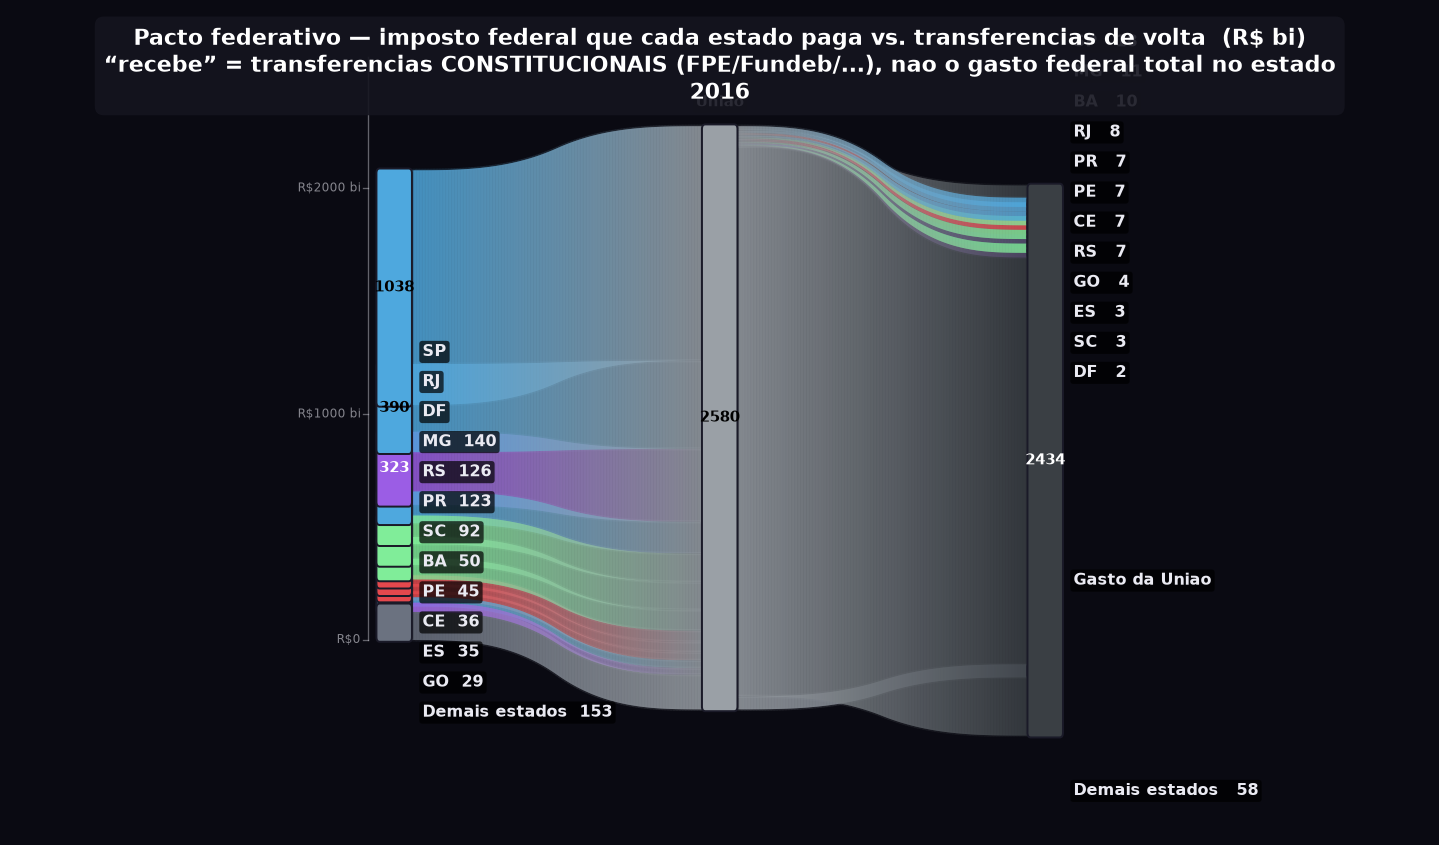

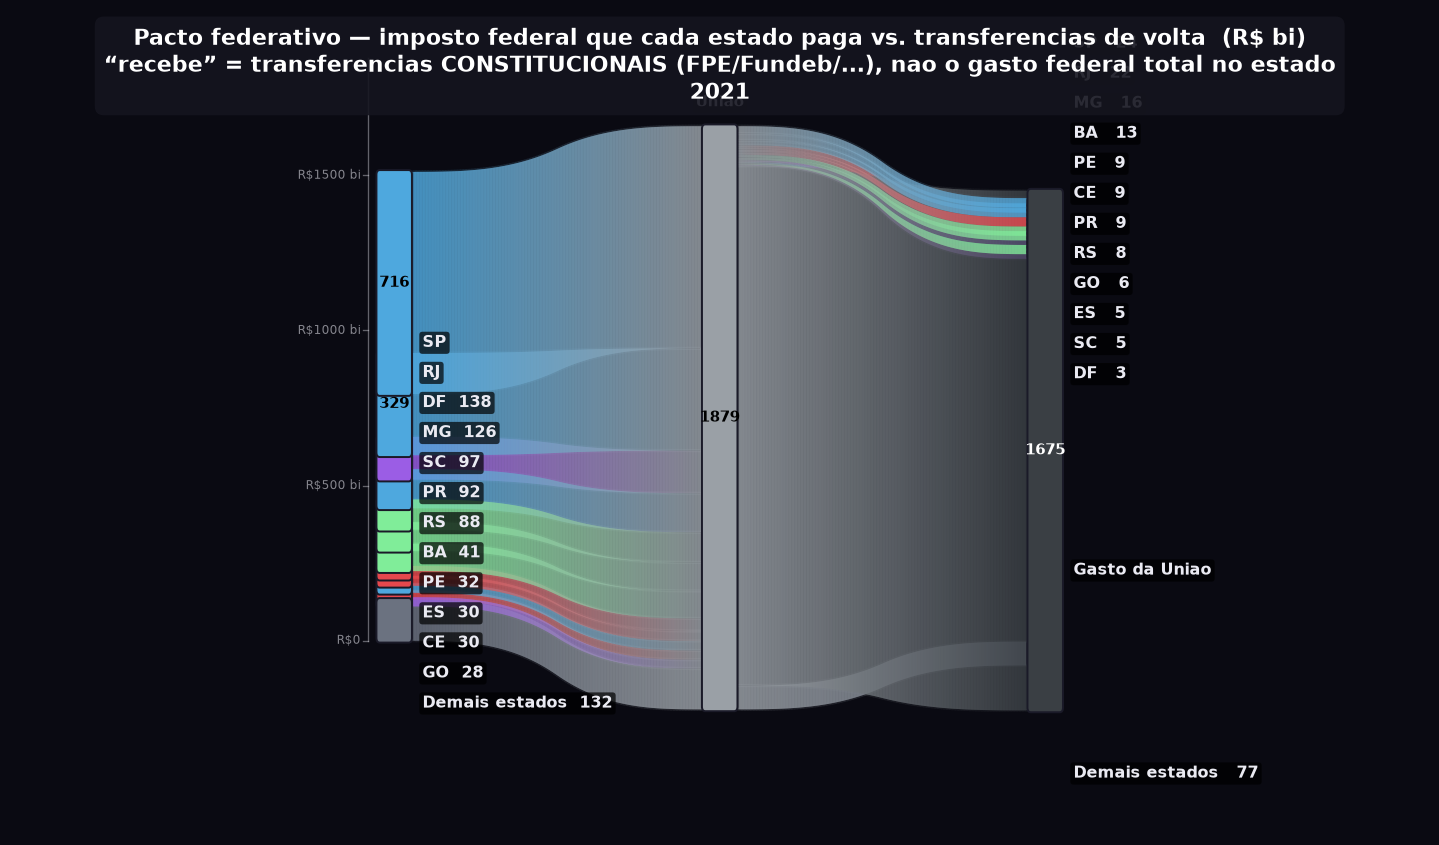

In [12]:
TITLE = ("Pacto federativo — imposto federal que cada estado paga vs. transferencias de volta  (R$ bi)\n"
         "“recebe” = transferencias CONSTITUCIONAIS (FPE/Fundeb/...), nao o gasto federal total no estado")

still_design = dict(
    figsize=(16, 9), dpi=95, font_size=12, title_fontsize=17, padding=2.8,
    margin_top=0.17, margin_bottom=0.21,
    ranking_mode=True, stacked_mode=True,            # the race: reorder AND resize
    stacked_gap=0.0,                                 # conserved flow: no inter-node gaps, so the
                                                     # 13-node columns align with the single "Uniao" hub
    theme="dark", link_glow=1, link_alpha=0.55, n_segments=100,
    yaxis_node=anchor, value_prefix="R$", yaxis_suffix=" bi",   # reais axis on the paying layer
    yaxis_gap=0.15, layer0_label_side="right",       # axis hugs the states; names on the right
)

year_to_index = {f["time_label"]: i for i, f in enumerate(sk.frames)}
still_paths = []
for yr in (str(Y0), str(Y1)):
    if yr not in year_to_index:
        continue
    p = os.path.join(ASSETS, f"br_fiscal_{yr}.png")
    sk.save_frame(p, frame_index=year_to_index[yr], title=TITLE, **still_design)
    still_paths.append(p)
    print("saved", p)

for p in still_paths:
    display(show(p, w=1000))



### One short animation 🎬

A tiny clip to prove the motion, with the **full** reel design: dark theme, glow, the R\$ axis, and the
total‑tax overlay. We keep it short for speed. The cell **skips gracefully** if FFmpeg isn't installed —
but if it is, you'll see the columns reorder and grow as the years pass.


In [13]:
sample_mp4 = os.path.join(ASSETS, "br_fiscal_sample.mp4")
try:
    sk.animate(
        sample_mp4,
        figsize=(16, 9), fps=24, duration_seconds=8, quality="medium", n_workers=2,
        title=TITLE,
        font_size=12, title_fontsize=18, padding=2.8,
        margin_top=0.17, margin_bottom=0.21,
        ranking_mode=True, stacked_mode=True,
        stacked_gap=0.0,                                              # conserved flow: columns align with the hub
        theme="dark", link_glow=1, link_alpha=0.55, n_segments=100,
        yaxis_node=anchor, value_prefix="R$", yaxis_suffix=" bi",
        yaxis_gap=0.15, layer0_label_side="right",
        overlay_series=total_paga, overlay_x_labels=xlabels,
        overlay_label="Imposto federal arrecadado no ano  (R$ bi)",
        overlay_color="#FFB000", overlay_value_suffix=" bi", overlay_badge="UNIAO",
        overlay_band=(0.18, 0.56),                                    # push the line chart lower
    )
    from IPython.display import Video
    print("rendered:", sample_mp4)
    display(Video(sample_mp4, embed=True, width=900))
except Exception as e:
    print("Skipping the MP4 (FFmpeg likely not installed) — the stills above tell the story.")
    print("Reason:", repr(e))


Settings (MULTI-LAYER PARALLEL):
  - Layers: 3
  - Nodes per layer: [13, 1, 14]
  - FPS: 24, Duration: 8s
  - Quality: medium
  - Total frames: 192
  - Gradient segments: 100
  - Positioning mode: Stacked + Ranking
  - Dynamic color mode: Static

Pre-computing 192 frames...
  Pre-computation: 0.02s
  Workers: 2

Rendering on 2 parallel processes...


  Parallel rendering: 110.25s (1.7 fps)

Concatenating 2 chunks...
  Concatenation: 0.14s

Animation saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\br_fiscal_sample.mp4
Total time: 110.39s (1.7 effective fps)
rendered: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\br_fiscal_sample.mp4



## 9 · Recap, honesty notes & exercises

🎉 **You built a real three‑layer reel** — from two free, no‑auth public sources to an animated gradient
Sankey that shows Brazil's federative pact as money: tax in, transfers back, and the honest remainder that
stays federal — with **no external project files**.

**The pipeline, in one breath:** fetch `paga` (**Receita Federal `.ODS`**, parsed with `odfpy`) + `recebe`
(**Tesouro Transparente CKAN**, with the 2016 split + pre‑2016 consolidated quirks) → optional **IPCA**
deflator for a real‑R\$ view → wrap both into a per‑state `fiscal_balance` (cached) → emit **two link hops
per year** (`state → União`, `União → state ‑with‑trailing‑space`) + a **`Gasto da União`** balance link so
the hub **conserves** → **top‑12 + "Demais estados"** aggregation → fixed **region colours** → **total‑tax**
overlay → `from_dataframe` with **three** layers → `save_frame` stills + `animate` with the dark theme, the
**R\$ axis** (`value_prefix="R$"`, `yaxis_suffix=" bi"`) and `overlay_band`.

### 💙 Honesty notes (the things that make it trustworthy)

1. **`recebe` is constitutional transfers only.** It's the redistribution mechanism of the pact
   (FPE/FPEX/Fundeb/ITR) — **not** total federal spending in the state.
2. **`Gasto da União` is national spending, and much of it returns** — INSS pensions, SUS health funding,
   federal payroll in each state. A naive `paga − recebe` reading **overstates** the imbalance.
3. **The hub conserves.** Every year, tax in == transfers + `Gasto da União` out; the build asserts it.
4. **Nominal by default.** Set `REAL = True` to deflate to constant R\$ via the IPCA and separate real
   growth from inflation.

### 🧪 Try it yourself

1. **Real R\$.** Set `REAL = True` (base 2021) and re‑run — see how much of the 2016→2021 rise was price,
   not volume.
2. **Net flow per state.** Add `net = paga − recebe` labels (via `node_value_labels`) to mark net
   contributors vs net recipients.
3. **More or fewer names.** Change `TOP_N` (8 or 16) and watch the `Demais estados` bucket grow or shrink.
4. **Per‑capita.** Divide `paga`/`recebe` by state population — a fairer, very different ranking emerges.
5. **Region grain.** Aggregate states into the five `regiões` (N/NE/CO/SE/S) for a 5‑node left column.
6. **Recent years (advanced, needs GCP).** The same arrecadação is on **Base dos Dados / BigQuery**
   (`basedosdados.br_rf_arrecadacao.uf`, to 2024) — extending the window past 2021 requires a Google
   Cloud project for BigQuery auth, so we deliberately left it out of this no‑auth notebook.

### 🔗 Links

- The library: `gradient_sankey.py` (repo root) · `pip install gradient-sankey`
- **Receita Federal** arrecadação por estado (`.ODS`):
  https://www.gov.br/receitafederal/pt-br/acesso-a-informacao/dados-abertos/receitadata/arrecadacao/arrecadacao-por-estado
- **Tesouro Transparente** (constitutional transfers, CKAN):
  https://www.tesourotransparente.gov.br/ckan/dataset/transferencias-constitucionais-para-estados
- **BCB SGS** series 433 (IPCA): https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados?formato=json
- Companion tutorials: `notebooks/04_tutorial_co2.ipynb`, `notebooks/03_tutorial_energy.ipynb`,
  `notebooks/06_tutorial_refugees.ipynb`, `notebooks/02_tutorial_stablecoins.ipynb`

*Built com todo cuidado e carinho. Dados: Receita Federal (.ODS) + Tesouro Transparente (CKAN) + BCB SGS
(IPCA), todos públicos e sem autenticação. Happy hacking!*
